### Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
import statsmodels.api as sm
from scipy.optimize import minimize
from functools import *

### Import Dataset and Merge on Date

In [30]:
### Import Dataset and Merge on Date
stock_files = {
    'BAC': 'BAC.csv',
    'BLK': 'BLK.csv',
    'JPM': 'JPM.csv',
    'BRK-A': 'BRK-A.csv',
    'CME': 'CME.csv',
    'CG': 'CG.csv',
    'MS-PF': 'MS-PF.csv',
}

# Load and preprocess stock data
def load_stock_data(filename, ticker):
    df = pd.read_csv(filename, parse_dates=['Date'], dayfirst=True)
    df = df[(df['Date'] >= '2014-01-01') & (df['Date'] <= '2022-12-12')]
    if 'Adj Close' in df.columns:
        df = df[['Date', 'Adj Close']].rename(columns={'Adj Close': ticker})
    else: 
        df = df[['Date', 'Adjusted Close']].rename(columns={'Adjusted Close': ticker})
    return df

# Merge all stock data, keeping Date as the index
df = None
for ticker, file in stock_files.items():
    stock_df = load_stock_data(file, ticker)
    if df is None:
        df = stock_df.set_index('Date')
    else:
        df = df.merge(stock_df.set_index('Date'), left_index=True, right_index=True, how='inner')

# Load Fama-French 3-Factor Data
ff_3f = pd.read_csv('ff3.csv', parse_dates=['Date'])
ff_3f = ff_3f[(ff_3f['Date'] >= '2014-01-01') & (ff_3f['Date'] <= '2022-12-12')].set_index('Date')

/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_20300/3220572651.py:14: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df = pd.read_csv(filename, parse_dates=['Date'], dayfirst=True)


In [31]:
df.head()

,BAC,BLK,JPM,BRK-A,CME,CG,MS-PF
Date,,,,,,,
2014-01-02,14.601966,249.658493,46.532063,176320.0,56.066635,19.752230,15.423568
2014-01-03,14.883119,250.751923,46.891788,176336.0,56.958370,20.282877,15.503543
2014-01-06,15.109859,250.672226,47.163578,174500.0,56.383060,20.294167,15.509700
2014-01-07,14.964743,252.978668,46.619995,174195.0,55.965939,20.271582,15.595827
2014-01-08,15.037301,252.898941,47.059662,173284.0,55.419357,20.356256,15.626589


In [32]:
ff_3f.head()

,Mkt-RF,SMB,HML,RF
Date,,,,
2014-01-02,-0.88,-0.28,0.18,0.0
2014-01-03,0.03,0.36,0.04,0.0
2014-01-06,-0.34,-0.57,0.29,0.0
2014-01-07,0.68,0.38,-0.37,0.0
2014-01-08,0.04,-0.01,-0.11,0.0


Check the date availability of each stock. 

### Calculate individual stock returns, covariance, risk-free rate

In [ ]:
# Regular return 
returns = df.pct_change().dropna() # Index is now Date (datetime64[ns])
avg_returns = returns.mean() * 252 # Trading days: 252 
print(avg_returns)

BAC      0.092978
BLK      0.104065
JPM      0.118740
BRK-A    0.079881
CME      0.192008
CG       0.044276
MS-PF    0.062708
dtype: float64


In [40]:
# Log return
log_returns = np.log(df / df.shift(1)).dropna()
log_avg_returns = log_returns.mean() * 252
print(log_avg_returns)

BAC      0.048574
BLK      0.068871
JPM      0.085748
BRK-A    0.063028
CME      0.161440
CG      -0.013818
MS-PF    0.055644
dtype: float64


In [45]:
# Annualized covariance matrix 
cov_matrix = returns.cov() * 252 
print(cov_matrix, "\n")


log_cov_matrix = log_returns.cov() * 252 
print(log_cov_matrix)

            BAC       BLK       JPM     BRK-A       CME        CG     MS-PF
BAC    0.088687  0.058942  0.068859  0.039354  0.039960  0.052959  0.010865
BLK    0.058942  0.070179  0.051703  0.036324  0.036748  0.051923  0.011005
JPM    0.068859  0.051703  0.065786  0.036137  0.037851  0.048502  0.011904
BRK-A  0.039354  0.036324  0.036137  0.033636  0.026912  0.030961  0.008099
CME    0.039960  0.036748  0.037851  0.026912  0.060033  0.031188  0.011044
CG     0.052959  0.051923  0.048502  0.030961  0.031188  0.115757  0.014146
MS-PF  0.010865  0.011005  0.011904  0.008099  0.011044  0.014146  0.013686 

            BAC       BLK       JPM     BRK-A       CME        CG     MS-PF
BAC    0.089021  0.059414  0.069171  0.039535  0.040821  0.054212  0.011158
BLK    0.059414  0.070569  0.052085  0.036501  0.037323  0.052816  0.011049
JPM    0.069171  0.052085  0.066162  0.036417  0.038888  0.049611  0.012446
BRK-A  0.039535  0.036501  0.036417  0.033757  0.027463  0.031506  0.008399
CME    0.0

In [48]:
rf_rate = (1 + ff_3f['RF'].mean() / 100) ** 252 - 1
# rf_rate = ff_3f['RF'].mean() * 252 
print(rf_rate)

0.007363167261713377


### Now, lets calculate the optimal portfolio weights
1. SLSQP minimizes a function of several variables with any combination of bounds, equality and inequality constraints. 
2. SLSQP is ideal for mathematical problems for which the objective function and the constraints are twice continuously differentiable. 
 <\br> https://docs.quantum.ibm.com/api/qiskit/0.41/qiskit.algorithms.optimizers.SLSQP

In [64]:
# Diversified portfolio allocation - unconstrainted optimization 
def objective(weights):
    # Assuming weights can take any value, and no bounds are applied
    portfolio_return = np.dot(weights, avg_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (portfolio_return - rf_rate) / portfolio_volatility
    return -sharpe_ratio

# Equality constraint for sum of weights equal to 1
constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})

# Unconstrained optimization 
initial_guess = np.ones(len(returns.columns)) / len(returns.columns)
result = minimize(objective, initial_guess, method='SLSQP', constraints=constraints)

optimal_weights = result.x

# Portfolio metrics
portfolio_return = np.dot(optimal_weights, avg_returns)
portfolio_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix, optimal_weights)))

# Display portfolio allocation 
print(f"Optimal Portfolio Weights: {dict(zip(returns.columns, np.round(optimal_weights, 4)))}")
print(f"Portfolio Expected Return (Annualized): {portfolio_return:.4f}")
print(f"Portfolio Volatility (Annualized): {portfolio_volatility:.4f}")

Optimal Portfolio Weights: {'BAC': -0.3717, 'BLK': 0.0551, 'JPM': 0.4392, 'BRK-A': -0.1055, 'CME': 0.6849, 'CG': -0.1814, 'MS-PF': 0.4794}
Portfolio Expected Return (Annualized): 0.1684
Portfolio Volatility (Annualized): 0.1907


In [68]:
# Diversified portfolio allocation - constrainted optimization
def objective(weights):
    portfolio_return = np.dot(weights, avg_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (portfolio_return - rf_rate) / portfolio_volatility
    return -sharpe_ratio

max_weight = 0.5
constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})
bounds = [(0, max_weight) for _ in range(len(returns.columns))]
initial_guess = np.ones(len(returns.columns)) / len(returns.columns)
result = minimize(objective, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
optimal_weights = result.x

# Portfolio metrics
portfolio_return = np.dot(optimal_weights, avg_returns)
portfolio_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix, optimal_weights)))

# Display portfolio allocation 
print(f"Optimal Portfolio Weights: {dict(zip(returns.columns, np.round(optimal_weights, 4)))}")
print(f"Portfolio Expected Return (Annualized): {portfolio_return:.4f}")
print(f"Portfolio Volatility (Annualized): {portfolio_volatility:.4f}")

# Weight - depend on correlation 
# Input - correlation matrix, make the matrix diagonal 

Optimal Portfolio Weights: {'BAC': 0.0, 'BLK': 0.0, 'JPM': 0.0, 'BRK-A': 0.0, 'CME': 0.5, 'CG': 0.0, 'MS-PF': 0.5}
Portfolio Expected Return (Annualized): 0.1274
Portfolio Volatility (Annualized): 0.1548


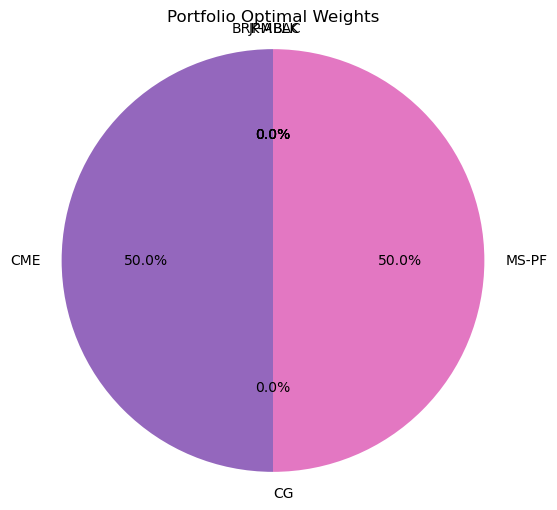

In [66]:
# +Pie Chart of Optimal Weights
plt.figure(figsize=(6, 6))
plt.pie(optimal_weights, labels=returns.columns, autopct='%1.1f%%', startangle=90)
plt.title("Portfolio Optimal Weights")
plt.axis('equal')
plt.show()

### Regression: Testing the FF3 model

In [69]:
# Calculate daily portfolio returns
portfolio_returns_daily = returns.dot(optimal_weights)
portfolio_returns_daily = pd.DataFrame(portfolio_returns_daily, columns=['Portfolio_Return'], index=returns.index)
print(portfolio_returns_daily)

# Merge with Fama-French data (both have Date as datetime index)
data_for_regression = portfolio_returns_daily.merge(ff_3f, left_index=True, right_index=True, how='inner')

# Calculate daily portfolio excess returns
data_for_regression['Portfolio_Excess_Return'] = data_for_regression['Portfolio_Return'] - data_for_regression['RF']

# Define dependent and independent variables
y = data_for_regression['Portfolio_Excess_Return']
X = data_for_regression[['SMB', 'HML']]           # Exclude RF from X since it's already subtracted
X = sm.add_constant(X)

# Run the regression
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())


            Portfolio_Return
Date                        
2014-01-03          0.010545
2014-01-06         -0.004852
2014-01-07         -0.000922
2014-01-08         -0.003897
2014-01-09          0.002819
...                      ...
2020-03-26          0.084567
2020-03-27         -0.020245
2020-03-30          0.023972
2020-03-31         -0.004852
2020-04-01         -0.029735

[1572 rows x 1 columns]
                               OLS Regression Results                              
Dep. Variable:     Portfolio_Excess_Return   R-squared:                       0.051
Model:                                 OLS   Adj. R-squared:                  0.049
Method:                      Least Squares   F-statistic:                     41.82
Date:                     Fri, 07 Mar 2025   Prob (F-statistic):           2.02e-18
Time:                             20:35:26   Log-Likelihood:                 4992.9
No. Observations:                     1572   AIC:                            -9980.
Df Residua

### Now, what if we use an equally weighted portfolio?

In [70]:
# Portfolio expected return and volatility (annualized)
portfolio_return2 = np.dot(initial_guess, avg_returns)                                     # Annualized expected return
portfolio_volatility2 = np.sqrt(np.dot(initial_guess.T, np.dot(cov_matrix, initial_guess))) # Annualized volatility

print(f"\nPortfolio Expected Return (Annualized): {portfolio_return2:.4f}")
print(f"Portfolio Volatility (Annualized): {portfolio_volatility2:.4f}")


Portfolio Expected Return (Annualized): 0.0992
Portfolio Volatility (Annualized): 0.1958


### Some visualizations

/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_20300/3440097792.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annualized_returns = cumulative_returns.resample('Y').last()  # Take the last value of each year


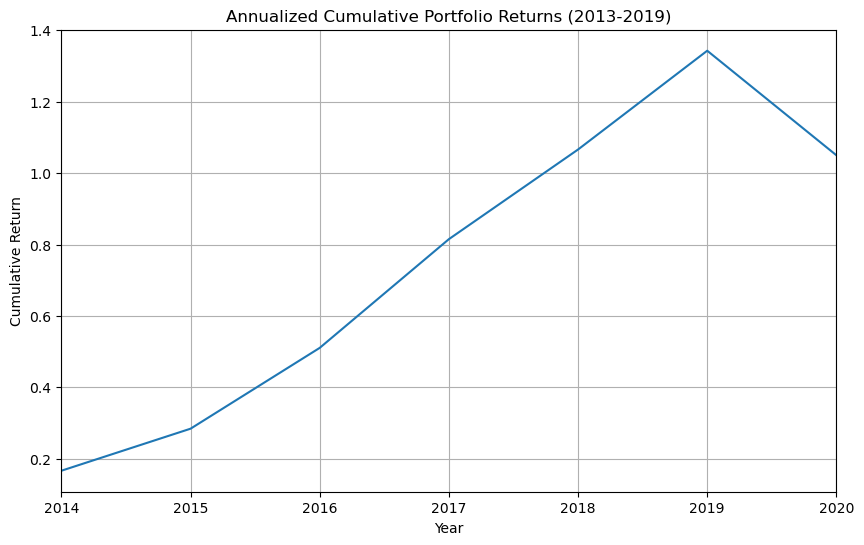

In [71]:
# Visualization 1: Annualized cumulative returns
cumulative_returns = (1 + portfolio_returns_daily['Portfolio_Return']).cumprod() - 1
annualized_returns = cumulative_returns.resample('Y').last()  # Take the last value of each year

# Plot annualized cumulative returns
plt.figure(figsize=(10, 6))
annualized_returns.plot()
plt.title("Annualized Cumulative Portfolio Returns (2013-2019)")
plt.xlabel("Year")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

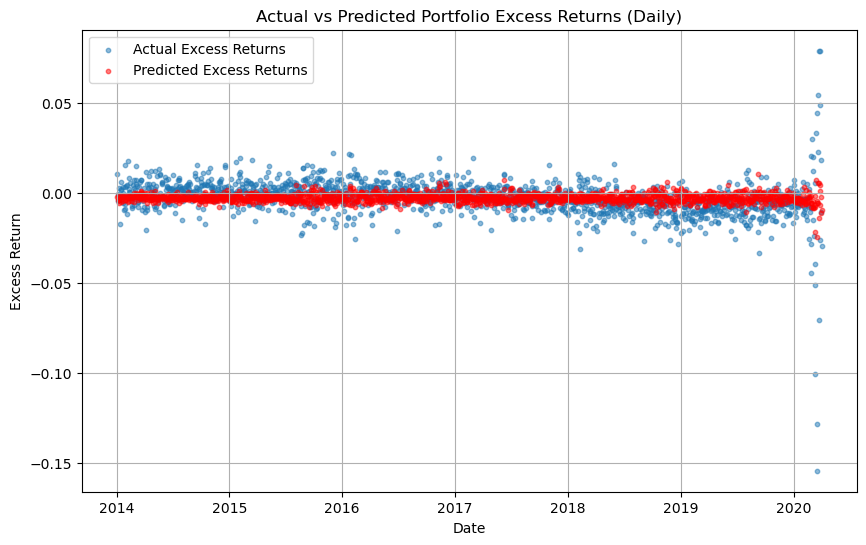

In [73]:
predicted_excess_returns = results.fittedvalues
plt.figure(figsize=(10, 6))
plt.scatter(data_for_regression.index, y, label="Actual Excess Returns", alpha=0.5, s=10)
plt.scatter(data_for_regression.index, predicted_excess_returns, color='red', label="Predicted Excess Returns", alpha=0.5, s=10)
plt.title("Actual vs Predicted Portfolio Excess Returns (Daily)")
plt.xlabel("Date")
plt.ylabel("Excess Return")
plt.legend()
plt.grid(True)
plt.show()